In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from tqdm import tqdm
from scipy.cluster.hierarchy import  linkage,dendrogram
from sklearn.model_selection import train_test_split
from sklearn.cluster import  KMeans
import matplotlib.pyplot as plt

In [8]:
df=pd.read_csv("../Datasets/milk.csv",index_col=0)

In [9]:
scaler=StandardScaler().set_output(transform="pandas")
df_scale=scaler.fit_transform(df)

In [13]:
k_means=KMeans(random_state=25,n_clusters=3,n_init=10)
k_means.fit(df_scale)
print(k_means.labels_)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 2 2]


In [14]:
wss=[]
for i in range(2,11):
    cluster=KMeans(random_state=25,n_clusters=i,n_init=10)
    cluster.fit(df_scale)
    wss.append([i,cluster.inertia_])
wss_df=pd.DataFrame(wss,columns=["cluster","inertia"]).sort_values(by="inertia",ascending=False)
print(wss_df)



   cluster    inertia
0        2  49.854660
1        3  30.822631
2        4  18.390116
3        5  13.355156
4        6  10.586920
5        7   7.851896
6        8   6.075610
7        9   4.883256
8       10   3.693505


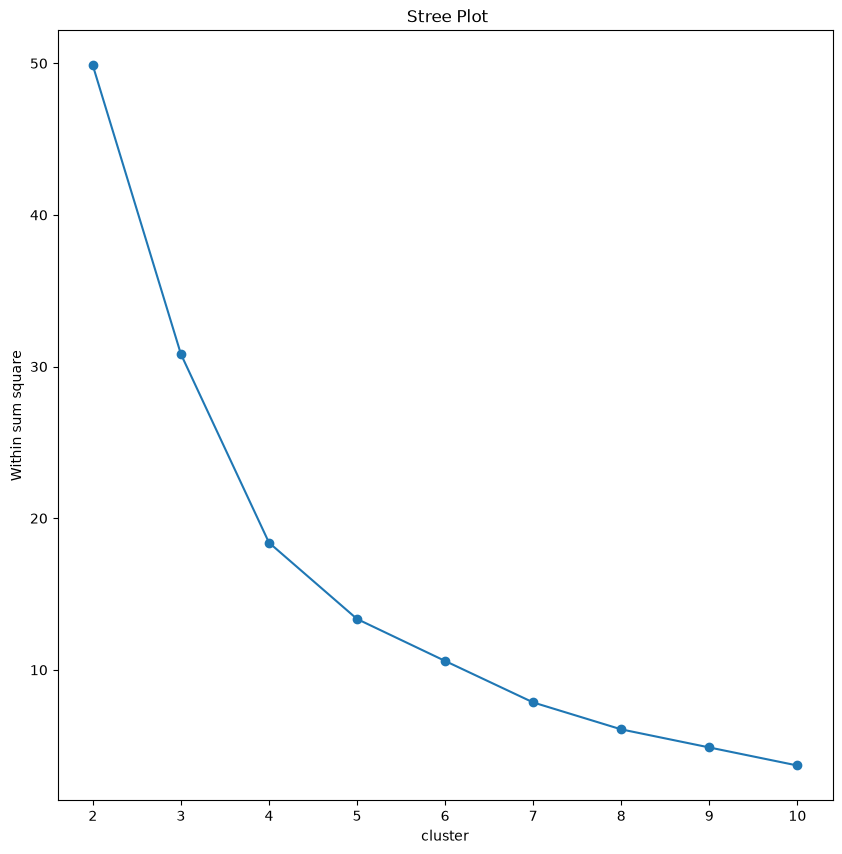

In [22]:
plt.figure(figsize=(10,10))
plt.scatter(wss_df["cluster"],wss_df["inertia"])
plt.plot(wss_df["cluster"],wss_df["inertia"])
plt.title(" Stree Plot")
plt.xlabel("cluster")
plt.ylabel("Within sum square")
plt.show()

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

scores = []

for i in range(2, 11):
    cluster = KMeans(
        random_state=25,
        n_clusters=i,
        n_init=10
    )
    cluster.fit(df_scale)
    wss = cluster.inertia_
    sil_score = silhouette_score(
        df_scale,
        cluster.labels_
    )

    scores.append([i, wss, sil_score])


score_df = pd.DataFrame(
    scores,
    columns=["cluster", "inertia", "silhouette_score"]
)

print(score_df)


   cluster    inertia  silhouette_score
0        2  49.854660          0.525851
1        3  30.822631          0.539160
2        4  18.390116          0.437608
3        5  13.355156          0.409260
4        6  10.586920          0.386462
5        7   7.851896          0.398780
6        8   6.075610          0.397209
7        9   4.883256          0.406707
8       10   3.693505          0.407573
